In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_theme()

# Testing the Phillips Curve

The Phillips Curve argues that there is a negative correlation between inflation and unemployment - when inflation increases, unemployment decreases, and vice versa. The mechanism this occurs by is hypothesised as such:

1. Suppose that unemployment has decreased
2. Employees have more bargaining power, because of the decrease in supply of labor, and can demand higher wages
3. Higher wages lead to higher costs of production
4. These costs are passed onto consumers, leading to an increase in the general price level (inflation)

This traditional formulation was empirically disproven by the oil shock after 1973. This brought on a decade of stagflation, where increases in inflation did not correlate with decreases in unemployment. It was replaced with the Expectations Augmented Phillips Curve, which provides a fuller picture, taking the long-run and worker expectations into account:

1. In the long run, employees will see their real wages decline
2. This will incite them to demand greater wages
3. This will force forms to lay off workers
4. Employment will return to its natural rate, but inflation will still be high


## The Traditional Phillips Curve

By plotting unemployment and inflation data, we can get a general idea of their correlation. I will use FRED's annual inflation data for the US, not seasonally adjusted, and its monthly unemployment data, seasonally adjusted.

In [35]:
inf = pd.read_csv('inf.csv', index_col='observation_date', parse_dates=True).rename(columns={'FPCPITOTLZGUSA': 'inflation_rate'})
inf

,inflation_rate
observation_date,
1960-01-01,1.457976
1961-01-01,1.070724
1962-01-01,1.198773
1963-01-01,1.239669
1964-01-01,1.278912
...,...
2020-01-01,1.233584
2021-01-01,4.697859
2022-01-01,8.002800


In [36]:
unemp = pd.read_csv('unemp.csv', index_col='observation_date', parse_dates=True).rename(columns={'UNRATE': 'unemployment_rate'})
unemp

,unemployment_rate
observation_date,
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5
...,...
2025-10-01,NaN
2025-11-01,4.5
2025-12-01,4.4


Now we have to merge the dataframes. Our unemployment data is monthly, so we have to resample it to an annual basis. Annual unemployment is calculated as the average of the 12 monthly figures.

In [37]:
unemp_inf = pd.merge(unemp.resample('YS').mean(), inf, how='left', on='observation_date')
unemp_inf.tail(20)

,unemployment_rate,inflation_rate
observation_date,,
2007-01-01,4.616667,2.852672
2008-01-01,5.800000,3.839100
2009-01-01,9.283333,-0.355546
2010-01-01,9.608333,1.640043
2011-01-01,8.933333,3.156842
2012-01-01,8.075000,2.069337
2013-01-01,7.358333,1.464833
2014-01-01,6.158333,1.622223
2015-01-01,5.275000,0.118627


Our inflation data is missing for many dates. We must drop the rows where we don't have matching unemployment and inflation data.

In [38]:
unemp_inf = unemp_inf.dropna()
unemp_inf

,unemployment_rate,inflation_rate
observation_date,,
1960-01-01,5.541667,1.457976
1961-01-01,6.691667,1.070724
1962-01-01,5.566667,1.198773
1963-01-01,5.641667,1.239669
1964-01-01,5.158333,1.278912
...,...,...
2020-01-01,8.100000,1.233584
2021-01-01,5.350000,4.697859
2022-01-01,3.650000,8.002800


<Axes: xlabel='observation_date'>

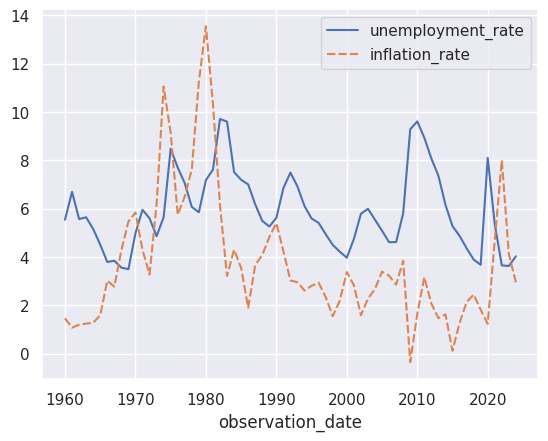

In [39]:
sns.lineplot(unemp_inf)

What's cool about this specific data is that we can trace the history of economic thought, specifically the Phillips' Curve, through it. If we look at the 1960-70 period, we see the negative correlation the traditional model argues for. 1970 onwards, we see that correlation completely collapse.

<Axes: xlabel='observation_date'>

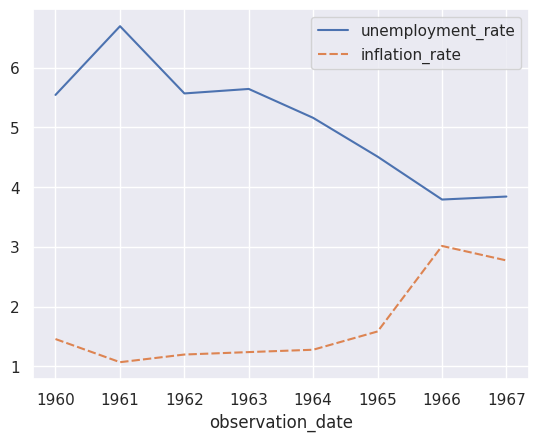

In [40]:
sixties = unemp_inf['1960-01-01':'1967-01-01']
sns.lineplot(sixties)

In [41]:
sixties['unemployment_rate'].corr(sixties['inflation_rate']) 

np.float64(-0.8812049507014807)

We see a reasonably strong negative correlation, as Bill Phillips demonstrated.

<Axes: xlabel='inflation_rate', ylabel='unemployment_rate'>

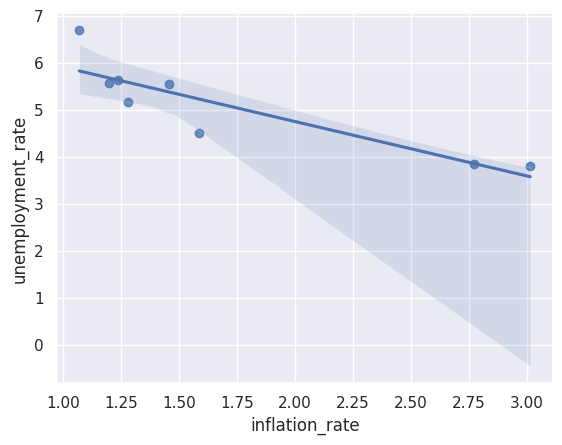

In [42]:
sns.regplot(x=sixties['inflation_rate'], y=sixties['unemployment_rate'])

## Stagflation

<Axes: xlabel='observation_date'>

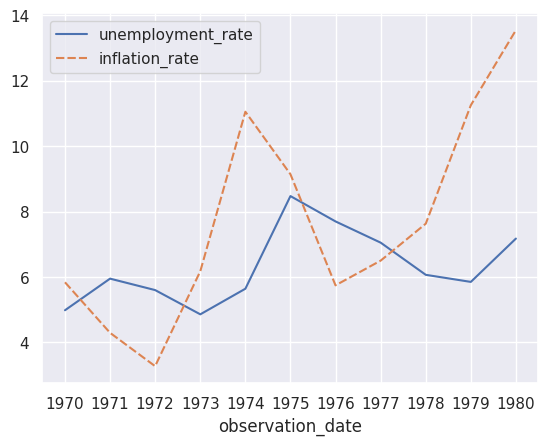

In [43]:
seventies = unemp_inf['1970-01-01':'1980-01-01']
sns.lineplot(seventies)

In [44]:
seventies['unemployment_rate'].corr(seventies['inflation_rate'])

np.float64(0.2663010944577987)

We see a weak positive correlation. Simultaneous highs of inflation and unemployment seemed to disprove the Traditional Phillips Curve.

<Axes: xlabel='inflation_rate', ylabel='unemployment_rate'>

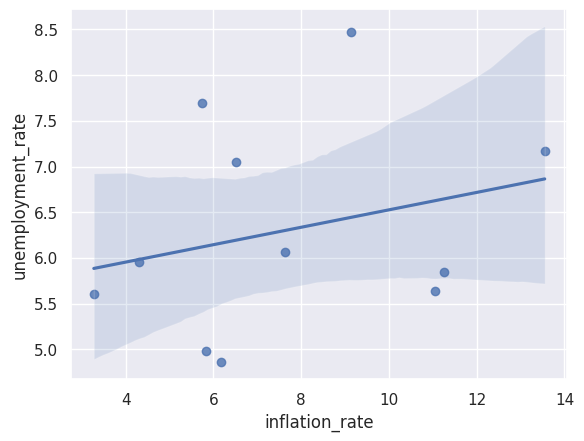

In [45]:
sns.regplot(x=seventies['inflation_rate'], y=seventies['unemployment_rate'])

## The Short-run

Economists do not hold the traditional Phillips Curve to be false, but merely a short-run theory. Now I'm going to test if this is true: where short-run is equal to one year, does a strong negative correlation between unemployment and inflation hold?

To do this, we need to get monthly YoY inflation data. FRED gives us 'Consumer Price Index for All Urban Consumers: All Items in U.S. City Average'. We will need to convert this to percentage changes, but it should work.

In [46]:
cpi_monthly = pd.read_csv('inf_monthly.csv', index_col='observation_date', parse_dates=True).rename(columns={'CPIAUCSL': 'CPI'})
inf_monthly = (cpi_monthly.pct_change(12) * 100).dropna().rename(columns={'CPI': 'inflation_rate'})
inf_monthly

,inflation_rate
observation_date,
1948-01-01,10.242086
1948-02-01,9.481961
1948-03-01,6.818182
1948-04-01,8.272727
1948-05-01,9.384966
...,...
2025-09-01,3.022572
2025-11-01,2.696444
2025-12-01,2.653304


Now that we have our data, we can get the average negative correlation between inflation and unemployment over twelve-month periods.

In [47]:
unemp_inf_monthly = pd.merge(unemp, inf_monthly, 'right', on='observation_date')
unemp_inf_monthly.dropna()

,unemployment_rate,inflation_rate
observation_date,,
1948-01-01,3.4,10.242086
1948-02-01,3.8,9.481961
1948-03-01,4.0,6.818182
1948-04-01,3.9,8.272727
1948-05-01,3.5,9.384966
...,...,...
2025-09-01,4.4,3.022572
2025-11-01,4.5,2.696444
2025-12-01,4.4,2.653304


<Axes: xlabel='observation_date'>

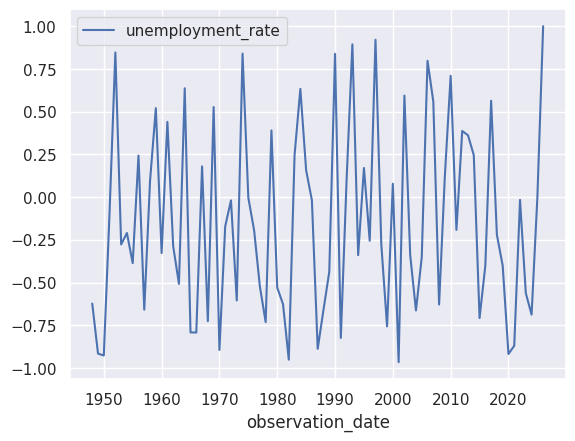

In [48]:
uninf_corr = unemp_inf_monthly.groupby(unemp_inf_monthly.index.year).corr().iloc[0::2,-1].unstack()
sns.lineplot(uninf_corr)

In [49]:
uninf_corr.mean()

unemployment_rate   -0.139759
dtype: float64

This shows us that, within 12-month periods, there is no strong correlation between unemployment and inflation. If unemployment rises in a month, inflation does not rise *simultaneously*. 

The biggest flaw with this analysis is, of course, that it fails to account for a time gap. Moreover, within 12-month periods there are only twelve total samples; averaging these does not make the reults especially meaningful. 

Instead of intra-short-run periods, let's try a 3-month gap/lag between unemployment and inflation - how does unemployment rising in one month correlate with inflation three months on?

## Adding a Lag

In [50]:
lagged_unempinf_monthly = unemp_inf_monthly.copy()
lagged_unempinf_monthly['inflation_rate'] = unemp_inf_monthly['inflation_rate'].shift(-3).dropna()
lagged_unempinf_monthly['unemployment_rate'].corr(lagged_unempinf_monthly['inflation_rate'])

np.float64(0.04095703974523833)

A weak positive correlation. Let's try generalising this function.

In [51]:
lags = range(24) # two year range
lag_correlations = {}

lagged_unempinf_monthly = unemp_inf_monthly.copy()

for lag in lags:
    lagged_unempinf_monthly['inflation_rate'] = unemp_inf_monthly['inflation_rate'].shift(-lag)
    lag_correlations[lag] = lagged_unempinf_monthly['unemployment_rate'].corr(lagged_unempinf_monthly['inflation_rate'])

pd.DataFrame.from_dict(lag_correlations, orient='index', columns=['correlation'])

,correlation
0,0.053951
1,0.048228
2,0.044783
3,0.040957
4,0.040465
5,0.042552
6,0.046893
7,0.054609
8,0.063986
9,0.075217


The positive correlation seems to grow by lag - meaning an increase in unemployment is correlated with an increase in inflation, generally, 1-24 months down the road. This seems counterintuitive.

One possible reason for this is that we average over the entire 1948-2026 period. Let's try breaking it down into different economic periods.

In [52]:
eras = {
    'pre_stagflation': ('1960-01-01', '1969-12-01'),
    'stagflation':     ('1970-01-01', '1983-12-01'),
    'great_moderation':('1984-01-01', '2007-12-01'),
    'post_gfc':        ('2008-01-01', '2026-02-01'),
}

lags = range(25) # two year range
lag_correlations = []
index = 0

for era, periods in eras.items():
    era_data = unemp_inf_monthly[periods[0]:periods[1]].dropna()
    for lag in lags:
        lag_correlations.append([era, lag, era_data['unemployment_rate'].corr(era_data['inflation_rate'].shift(-lag))])
        index += 1

lag_correlations_df = pd.DataFrame(lag_correlations, columns=['Era', 'Lag', 'Correlation'])
lag_correlations_df

,Era,Lag,Correlation
0,pre_stagflation,0,-0.807014
1,pre_stagflation,1,-0.816310
2,pre_stagflation,2,-0.827009
3,pre_stagflation,3,-0.837270
4,pre_stagflation,4,-0.847746
...,...,...,...
95,post_gfc,20,0.076844
96,post_gfc,21,0.071699
97,post_gfc,22,0.063336
98,post_gfc,23,0.050598


This gets us the correlation between inflation and unemployment, by era, across time lags from 0 to 23 months apart. Let's view this data era-by-era.

<Axes: xlabel='Lag', ylabel='Correlation'>

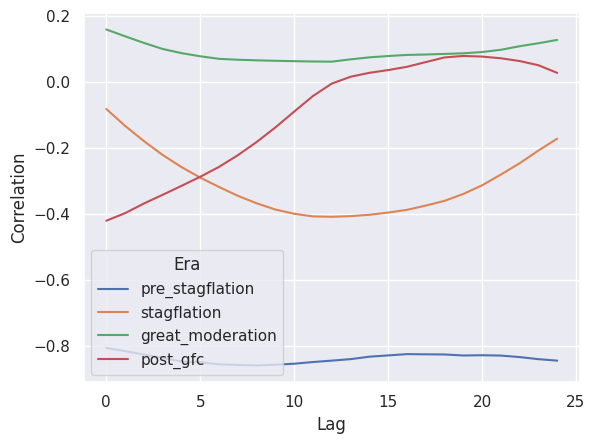

In [53]:
sns.lineplot(x=lag_correlations_df['Lag'], y=lag_correlations_df['Correlation'], hue=lag_correlations_df['Era'])

In [54]:
lag_correlations_df.groupby('Era').apply(lambda x : x.nsmallest(1, 'Correlation')) # The lowest correlation and its = lag by era

,,Lag,Correlation
Era,,,
great_moderation,62,12,0.061450
post_gfc,75,0,-0.420974
pre_stagflation,8,8,-0.859855
stagflation,37,12,-0.408968


The lessons of this analysis are interesting. For one, we see that in all eras save for the great moderation, we have a lag that corresponds to a reasonable negative correlation between inflation and unemployment. Save for the post great recession era, the lag between which changes in unemployment are most negatively correlated with changes in inflation seems to be between 8 to 12 months. 

The pre-stagflation era tells a simple story: unemployment is strongly negatively correlated with inflation at any lag, but especially around 8 months in.

The stagflation era does not turn out to be the empirical disprover it seemed to be: at a lag of 8 months, inflation and unemployment correlate with an n=-0.408968. In the social sciences, this is a moderately strong correlation.

The great moderation era is the only one where inflation and unemployment have no link at any lag. This era is associated with prudent monetary policy, most notably, with milder business cycles and generally less volatility in economic variables like inflation and unemployment.

The post-gfc eras 'strongest' lag is 0 months. That is to say, changes in unemployment *immediately* affect inflation. This was also a complicated period: the main factors in this anomaly are likely the Great Recession and its aftermath, and COVID.

## What explains the GFC?

<Axes: xlabel='observation_date'>

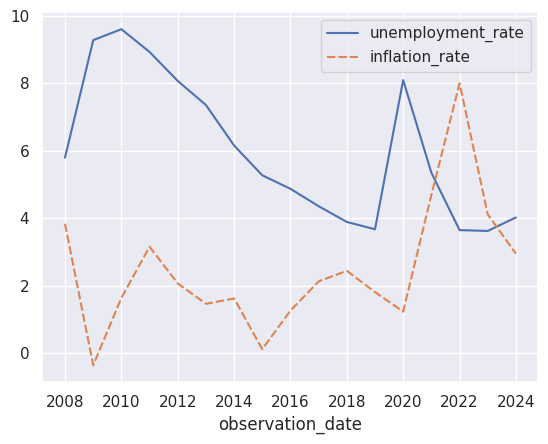

In [55]:
sns.lineplot(unemp_inf[eras['post_gfc'][0]:eras['post_gfc'][1]])

Inflation and unemployment both started off high in the GFC era. As the economy plunged into recession, the economy suffered a collapse in employment and deflation - simultaneously. This is likely due to the special nature of the crisis that occurred in 2008. 

In the aftermath and recovery, unemployment came down from its heights while inflation stayed stable. This is because the economy was operating below full employment, or at an unemployment gap. Closing this gap between current unemployment and the natural rate of unemployment should not generate inflationary pressure, and did not up till 2015, where we see a simultaneous increase in inflation and a continued decrease in unemployment past pre-crisis levels.

This decrease continued up till COVID. COVID was an especially unique crisis. The economy suffered highs in inflation you wouldn't usually see during a period of recession, because of supply-side issues caused by the pandemic. There is a brief lag here, which probably reflects the time between lockdowns -> supply-side issues. The collapse in inflation and unemployment, and the lag between those too, can be put down to the end of lockdowns, (the resolution of) supply-side issues, and also fiscal stimulus.

## Applying OLS Regression

A linear regression involves fitting a curve to a bunch of data points to see the relationship betweeen two variables, or in our case unemployment and inflation. Invariably, there will be some level of error (or residual) in each prediction: the difference between our predicted value of y given x and the actual value of y in a given data-point of x. An OLS regression aims to minimise the sum of each such residual (squared, to avoid weighting negative and positive residuals differently) between our data points and the curve we're fitting onto them.

The main numbers we care for are:
1. R-squared, or how much of the variation in inflation is explained by unemployment
2. coef, or slope, of unemployment_rate
3. P>|t| of unemployment_rate, which measures whether the relationship is statistically significant (p<0.05)

In [56]:
x = unemp_inf_monthly.unemployment_rate
x = sm.add_constant(x)
y = unemp_inf_monthly.inflation_rate

result = sm.OLS(y, x).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:         inflation_rate   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.729
Date:                Sat, 04 Apr 2026   Prob (F-statistic):             0.0988
Time:                        12:25:52   Log-Likelihood:                -2315.4
No. Observations:                 937   AIC:                             4635.
Df Residuals:                     935   BIC:                             4644.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.0046      0.32

An r^2 of 0.003 tells us the same story as our earliest analysis: there is no correlation between those two variables. The slope is positive and P>|t| tells us it's statistically insignificant. But what about by-era analysis?

### Pre-Stagflation

In [57]:
x = unemp_inf_monthly['1960-01-01':'1969-12-01'].unemployment_rate
x = sm.add_constant(x)
y = unemp_inf_monthly['1960-01-01':'1969-12-01'].inflation_rate

result = sm.OLS(y, x).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:         inflation_rate   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     220.4
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           9.18e-29
Time:                        12:25:52   Log-Likelihood:                -152.39
No. Observations:                 120   AIC:                             308.8
Df Residuals:                     118   BIC:                             314.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 7.6044      0.36

Here we see a strong correlation, as expected, an r^2 of 0.651. A negative slop of magnitute 1.1027, indicating a 1.1% fall in inflation with a 1% rise in unemployment. The relationship is highly statistically significant.

### Stagflation

In [58]:
x = unemp_inf_monthly['1970-01-01':'1983-12-01'].unemployment_rate
x = sm.add_constant(x)
y = unemp_inf_monthly['1970-01-01':'1983-12-01'].inflation_rate

result = sm.OLS(y, x).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:         inflation_rate   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.124
Date:                Sat, 04 Apr 2026   Prob (F-statistic):              0.291
Time:                        12:25:52   Log-Likelihood:                -432.89
No. Observations:                 168   AIC:                             869.8
Df Residuals:                     166   BIC:                             876.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.5759      1.09

R^2 of 0.007, a slop of -0.1649, and very high P-value mean this relationship is weak and statistically insignificant.

### Great Moderation

In [59]:
x = unemp_inf_monthly['1984-01-01':'2007-12-01'].unemployment_rate
x = sm.add_constant(x)
y = unemp_inf_monthly['1984-01-01':'2007-12-01'].inflation_rate

result = sm.OLS(y, x).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:         inflation_rate   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     7.431
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00681
Time:                        12:25:52   Log-Likelihood:                -427.18
No. Observations:                 288   AIC:                             858.4
Df Residuals:                     286   BIC:                             865.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.1690      0.35

R^2 of 0.025, and a positive slope and statistically significant relationship.

### Post-GFC

In [60]:
x = unemp_inf_monthly['2008-01-01':'2026-02-01'].unemployment_rate
x = sm.add_constant(x)
y = unemp_inf_monthly['2008-01-01':'2026-02-01'].inflation_rate

result = sm.OLS(y, x).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:         inflation_rate   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     46.31
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           9.89e-11
Time:                        12:25:52   Log-Likelihood:                -435.97
No. Observations:                 217   AIC:                             875.9
Df Residuals:                     215   BIC:                             882.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.7076      0.34

A weak R^2 of 0.177, negative slope and high statistical significance. In this era, a 1% increase in unemployment resulted in a 0.37% decrease in inflation.

Our data uses a monthly time-series. Inflation and unemployment data does not change much month from month ('autocorrelation'). OLS assumes independence, or that each data point of inflation and unemployment is unrelated to the previous data-point; this is not true of our data. We can see this in the very low Durbin-Watson values. Autocorrelation in OLS regressions tends to lead to inflated R^2 and t values, both overrating the link between our variables and statistical significance. In sum, these results are not precise.

## Conclusion

In this notebook, we started by looking at US economic data generally to measure the relationship between unemployment and inflation. We found that, in the aggregate, no such relationship seemed to exist. We then broke down our data into four eras and looked at them separately, enabling a more tailored analysis. We started by simply measuring correlation by era, then added a lag too. Finally, we tried out an OLS regression (with limitations) by era. Our dataset was limited to the US exclusively, and did not vary; we did vary technique, each with its own limitations (see their sections). These limitations should be taken into account, but we can derive some conclusions with reasonable confidence.

1. For the pre-stagflation era, there was a very tight negative correlation between inflation and unemployment. This peaked at 8 months of lag - a positive change in unemployment one month correlates heavily to a negative change in inflation eight months on. Our OLS regression was not lagged, but it gave us a slope of -1.1: a 1% rise in unemployment is associated with a 1.1pp fall in inflation.
2. For the stagflation era, the relationship broke down. Our OLS regression found a low R^2 and low statistical significance. However, adding a 12 month lag gave us a moderately high correlation of -0.408968, indicating the relationship existed but was quite lagged.
3. For the great moderation era, we found a statistically significant *positive* correlation between inflation and unemployment. This relationship was interesting, and is explainable quite simply: the Federal Reserve was looking at the same data as us. Under Volcker, the Fed worked rigorously to keep inflation under control - as a result, any increase would result in a tightening of policy, and increases in unemployment, and vice versa, perpetuating the positive correlation.
4. The post-GFC era got its own section in this notebook. The gist of it is that the noise in the data is because of two major events:
   1. The GFC itself, or its recovery to be exact. In the slow recovery that followed, the economy took its time returning to its NRU. In the meanwhile, inflation stayed stable and unemployment steadily decreased, which obviously weakens the relationship between our variables.
   2. COVID was a unique event; it resulted in both a demand and supply shock. With a brief period of lag, unemployment rose and so too did inflation, also complicating our data.

But the general idea is that the Phillips Curve should not simply be dismissed. Testing macroeconomic hypotheses is always complex: there actually isn't that much data, given how many factors change, country-to-country, year-to-year. Overall, though, the tight relationship in the pre-stagflation era and the fact we can explain away all the eras save for the stagflation should give us some confidence. On the other hand, in recent times the Phillips Curve has been on a losing streak, and of limited practical value not to mention - maybe its time is simply over.